# Introduction and Problem Statement

Delhivery, one of the India's largest logistics companies, aims to build a robust operating system for commerce by leveraging data insights. The goal of this assignment is to process the raw delivery data generated by data engineering pipelines. we will clean and transform the data, engineer new feature, and conduct exploratory analyses to help forecast delivery performance and gain business insights.

Objective: Delhivery's management wants to understand operational efficiencies by processing raw data from the engineering pipelines. Our aim is to:

*   Clean and sanitize the raw data to extract useful features.
*   Merge multiple rows that represent sections of one trip into aggregated trip-level metrics.
*   Engineer features such as trip durations, time differences between scheduled and actual trips, and city/state breakdown from combined name fields.
*   Perform in-depth Exploratory Data Analysis (EDA), including state-wise and corridor-wise analysis, to identify bottlenecks, outliers, and the relationship between roting estimates (OSRM) and actual performance.
*   Provide actionable business recommendations, such as identifying states or corridors with excessive delays and oppurtunities for capapcity planning.

# Data Loading and Preliminary Inspection

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv(r'/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/Delhivery Case Study/delhivery_data.csv')
display(df.head(10))

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (144867, 24)


In [10]:
print("Columns and Data Types:")
display(df.info())

Columns and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float

None

In [11]:
print('Missing Values:\n', df.isnull().sum())

Missing Values:
 data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64


In [12]:
display('Statistical Summary:\n', df.describe())

'Statistical Summary:\n'

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


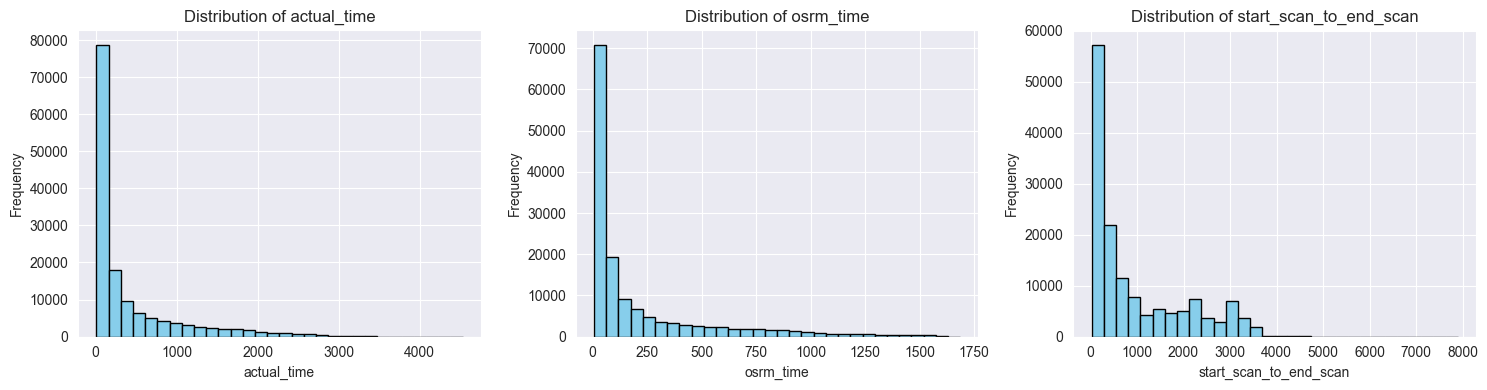

In [13]:
num_cols = ['actual_time', 'osrm_time', 'start_scan_to_end_scan']
fig, ax = plt.subplots(1, len(num_cols), figsize = (15,4))
for i, col in enumerate(num_cols):
    ax[i].hist(df[col].dropna(), bins = 30, color = 'skyblue', edgecolor = 'black')
    ax[i].set_title(f'Distribution of {col}')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Observation:
* Data has 1,44,867 rows and 24 columns.
* Data contains both numerical and categorical fields.
* Numerical features reveal skewed distributions and initial outliers. For example, the distribution of actual_time indicates several extremely high values, warranting further outlier investigation.
* A few columns (eg: is_cutoff, cutoff_factor, cutoff_timestamp, factor and segment_factor) are ambigious and may require further context.
* Time columns (eg: trip_creation_time, od_start_time and od_end_time) are currently in string format.

# Data Cleaning

## Time Format Conversion

In [14]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'], errors = 'coerce')
df['od_start_time'] = pd.to_datetime(df['od_start_time'], errors = 'coerce')
df['od_end_time'] = pd.to_datetime(df['od_end_time'], errors = 'coerce')

print('Missing Values after conversion:\n', df[['trip_creation_time', 'od_start_time', 'od_end_time']].isnull().sum())

Missing Values after conversion:
 trip_creation_time    0
od_start_time         0
od_end_time           0
dtype: int64


## Feature Engineering from Categorical Fields

In [15]:
def extract_state_city_unit(x):
  if isinstance(x, str):
    try:
      main_part = x.split('(')[0].strip()
      state = x.split('(')[-1].replace(')', '').strip()
      parts = main_part.split('_')
      if len(parts) == 3:
        city = parts[0].strip()
        unit_name = parts[1].strip()
        unit_code = parts[2].strip()
        return state, city, unit_name, unit_code
    except:
      pass
  return np.nan, np.nan, np.nan, np.nan

df[['source_state', 'source_city', 'source_unit', 'source_code']] = df['source_name'].apply(lambda x: pd.Series(extract_state_city_unit(x)))
df[['destination_state', 'destination_city', 'destination_unit', 'destination_code']] = df['destination_name'].apply(lambda x: pd.Series(extract_state_city_unit(x)))

display(df[['source_state', 'source_city', 'source_unit', 'source_code', 'destination_state', 'destination_city', 'destination_unit', 'destination_code']].head(10))

,source_state,source_city,source_unit,source_code,destination_state,destination_city,destination_unit,destination_code
0,Gujarat,Anand,VUNagar,DC,Gujarat,Khambhat,MotvdDPP,D
1,Gujarat,Anand,VUNagar,DC,Gujarat,Khambhat,MotvdDPP,D
2,Gujarat,Anand,VUNagar,DC,Gujarat,Khambhat,MotvdDPP,D
3,Gujarat,Anand,VUNagar,DC,Gujarat,Khambhat,MotvdDPP,D
4,Gujarat,Anand,VUNagar,DC,Gujarat,Khambhat,MotvdDPP,D
5,Gujarat,Khambhat,MotvdDPP,D,Gujarat,Anand,Vaghasi,IP
6,Gujarat,Khambhat,MotvdDPP,D,Gujarat,Anand,Vaghasi,IP
7,Gujarat,Khambhat,MotvdDPP,D,Gujarat,Anand,Vaghasi,IP
8,Gujarat,Khambhat,MotvdDPP,D,Gujarat,Anand,Vaghasi,IP
9,Gujarat,Khambhat,MotvdDPP,D,Gujarat,Anand,Vaghasi,IP


## Feature Extraction from Timestamps

In [16]:
df['trip_creation_year'] = df['trip_creation_time'].dt.year
df['trip_creation_month'] = df['trip_creation_time'].dt.month
df['trip_creation_day'] = df['trip_creation_time'].dt.day

display(df[['trip_creation_year','trip_creation_month','trip_creation_time']])

,trip_creation_year,trip_creation_month,trip_creation_time
0,2018,9,2018-09-20 02:35:36.476840
1,2018,9,2018-09-20 02:35:36.476840
2,2018,9,2018-09-20 02:35:36.476840
3,2018,9,2018-09-20 02:35:36.476840
4,2018,9,2018-09-20 02:35:36.476840
...,...,...,...
144862,2018,9,2018-09-20 16:24:28.436231
144863,2018,9,2018-09-20 16:24:28.436231
144864,2018,9,2018-09-20 16:24:28.436231
144865,2018,9,2018-09-20 16:24:28.436231


In [34]:
df['trip_creation_hour'] = df['trip_creation_time'].dt.hour

def time_of_day(hour):
    if pd.isnull(hour):
        return np.nan
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['trip_creation_hour'].apply(time_of_day)

df['distance_time_ratio'] = df.apply(lambda row: row['osrm_distance'] / row['osrm_time'] if row['osrm_time'] > 0 else np.nan, axis = 1)

display(df.head(10))

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,trip_creation_day,od_start_year,od_start_month,od_start_day,od_end_year,od_end_month,od_end_day,trip_creation_hour,time_of_day,distance_time_ratio
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20,2018,9,20,2018,9,20,2,Night,1.087755
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20,2018,9,20,2018,9,20,2,Night,1.086215
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20,2018,9,20,2018,9,20,2,Night,1.162125
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20,2018,9,20,2018,9,20,2,Night,1.139050
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20,2018,9,20,2018,9,20,2,Night,1.232230
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,20,2018,9,20,2018,9,20,2,Night,1.101555
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,20,2018,9,20,2018,9,20,2,Night,1.252294
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,20,2018,9,20,2018,9,20,2,Night,1.235352
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,20,2018,9,20,2018,9,20,2,Night,1.210000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,20,2018,9,20,2018,9,20,2,Night,1.182964


In [17]:
df['od_start_year'] = df['od_start_time'].dt.year
df['od_start_month'] = df['od_start_time'].dt.month
df['od_start_day'] = df['od_start_time'].dt.day

display(df[['od_start_year','od_start_month','od_start_day']])

,od_start_year,od_start_month,od_start_day
0,2018,9,20
1,2018,9,20
2,2018,9,20
3,2018,9,20
4,2018,9,20
...,...,...,...
144862,2018,9,20
144863,2018,9,20
144864,2018,9,20
144865,2018,9,20


In [18]:
df['od_end_year'] = df['od_end_time'].dt.year
df['od_end_month'] = df['od_end_time'].dt.month
df['od_end_day'] = df['od_end_time'].dt.day

display(df[['od_end_year','od_end_month','od_end_day']])

,od_end_year,od_end_month,od_end_day
0,2018,9,20
1,2018,9,20
2,2018,9,20
3,2018,9,20
4,2018,9,20
...,...,...,...
144862,2018,9,20
144863,2018,9,20
144864,2018,9,20
144865,2018,9,20


# Data Aggregation and Feature Engineering

## Aggregation strategy

In [19]:
aggregation_dict = {
    'trip_creation_time': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'source_center': 'first',
    'destination_center': 'first',
    'od_start_time': 'first',
    'od_end_time': 'last',
    'start_scan_to_end_scan': 'last',
    'actual_distance_to_destination': 'mean',
    'actual_time': 'sum',
    'osrm_time': 'sum',
    'osrm_distance': 'sum',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum'
}

grouped_df = df.groupby('trip_uuid').agg(aggregation_dict).reset_index()
display(grouped_df.head(10))

,trip_uuid,trip_creation_time,route_schedule_uuid,route_type,source_center,destination_center,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,trip-153671041653548748,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,1260.0,227.200310,15682.0,7787.0,10577.7647,1548.0,1008.0,1320.4733
1,trip-153671042288605164,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,58.0,26.689812,399.0,210.0,269.4308,141.0,65.0,84.1894
2,trip-153671043369099517,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,834.0,765.882048,112225.0,65768.0,89447.2488,3308.0,1941.0,2545.2678
3,trip-153671046011330457,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,IND401104AAA,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,100.0,14.264824,82.0,24.0,31.6475,59.0,16.0,19.8766
4,trip-153671052974046625,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,IND583201AAA,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,485.0,34.143901,556.0,207.0,266.2914,340.0,115.0,146.7919
5,trip-153671055416136166,2018-09-12 00:02:34.161600,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,Carting,IND600116AAB,IND600056AAA,2018-09-12 00:02:34.161600,2018-09-12 03:13:03.432532,60.0,11.469288,92.0,30.0,38.1953,60.0,23.0,28.0647
6,trip-153671066201138152,2018-09-12 00:04:22.011653,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,Carting,IND600044AAD,IND600048AAA,2018-09-12 00:04:22.011653,2018-09-12 01:42:22.349694,98.0,9.100510,24.0,13.0,12.0184,24.0,13.0,12.0184
7,trip-153671066826362165,2018-09-12 00:04:28.263977,thanos::sroute:d5b71ae9-a11a-4f52-bcb7-274b65e...,Carting,IND560043AAC,IND560064AAA,2018-09-12 00:04:28.263977,2018-09-12 03:00:55.163423,78.0,10.458714,122.0,65.0,54.2978,64.0,34.0,28.9203
8,trip-153671074033284934,2018-09-12 00:05:40.333071,thanos::sroute:a0e60427-16ad-4b17-b3b0-6a06643...,Carting,IND395023AAD,IND395004AAB,2018-09-12 00:05:40.333071,2018-09-12 05:16:28.581141,164.0,11.021178,306.0,50.0,53.8577,161.0,29.0,30.9358
9,trip-153671079956500691,2018-09-12 00:06:39.565253,thanos::sroute:a10888ff-f794-41e1-9b7a-7f62ef6...,Carting,IND110024AAA,IND110014AAA,2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.641302,35.0,16.0,19.9606,23.0,14.0,16.0860


In [20]:
grouped_df['trip_creation_time'] = pd.to_datetime(grouped_df['trip_creation_time'], errors = 'coerce')
grouped_df['od_start_time'] = pd.to_datetime(grouped_df['od_start_time'], errors = 'coerce')
grouped_df['od_end_time'] = pd.to_datetime(grouped_df['od_end_time'], errors = 'coerce')
grouped_df['trip_duration_minutes'] = (grouped_df['od_end_time'] - grouped_df['od_start_time']).dt.total_seconds() / 60

print('Aggregated DataFrame Shape:', grouped_df.shape)

display(grouped_df.head(10))

Aggregated DataFrame Shape: (14817, 17)


,trip_uuid,trip_creation_time,route_schedule_uuid,route_type,source_center,destination_center,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,trip_duration_minutes
0,trip-153671041653548748,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,1260.0,227.200310,15682.0,7787.0,10577.7647,1548.0,1008.0,1320.4733,2260.109800
1,trip-153671042288605164,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,58.0,26.689812,399.0,210.0,269.4308,141.0,65.0,84.1894,181.611874
2,trip-153671043369099517,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,834.0,765.882048,112225.0,65768.0,89447.2488,3308.0,1941.0,2545.2678,3934.362520
3,trip-153671046011330457,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,IND401104AAA,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,100.0,14.264824,82.0,24.0,31.6475,59.0,16.0,19.8766,100.494935
4,trip-153671052974046625,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,IND583201AAA,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,485.0,34.143901,556.0,207.0,266.2914,340.0,115.0,146.7919,718.349042
5,trip-153671055416136166,2018-09-12 00:02:34.161600,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,Carting,IND600116AAB,IND600056AAA,2018-09-12 00:02:34.161600,2018-09-12 03:13:03.432532,60.0,11.469288,92.0,30.0,38.1953,60.0,23.0,28.0647,190.487849
6,trip-153671066201138152,2018-09-12 00:04:22.011653,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,Carting,IND600044AAD,IND600048AAA,2018-09-12 00:04:22.011653,2018-09-12 01:42:22.349694,98.0,9.100510,24.0,13.0,12.0184,24.0,13.0,12.0184,98.005634
7,trip-153671066826362165,2018-09-12 00:04:28.263977,thanos::sroute:d5b71ae9-a11a-4f52-bcb7-274b65e...,Carting,IND560043AAC,IND560064AAA,2018-09-12 00:04:28.263977,2018-09-12 03:00:55.163423,78.0,10.458714,122.0,65.0,54.2978,64.0,34.0,28.9203,176.448324
8,trip-153671074033284934,2018-09-12 00:05:40.333071,thanos::sroute:a0e60427-16ad-4b17-b3b0-6a06643...,Carting,IND395023AAD,IND395004AAB,2018-09-12 00:05:40.333071,2018-09-12 05:16:28.581141,164.0,11.021178,306.0,50.0,53.8577,161.0,29.0,30.9358,310.804135
9,trip-153671079956500691,2018-09-12 00:06:39.565253,thanos::sroute:a10888ff-f794-41e1-9b7a-7f62ef6...,Carting,IND110024AAA,IND110014AAA,2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.641302,35.0,16.0,19.9606,23.0,14.0,16.0860,49.333390


## Augmenting Aggregated Data with Location Information

In [21]:
location_info = df[['trip_uuid', 'source_state', 'destination_state']].drop_duplicates(subset = 'trip_uuid')
grouped_df = grouped_df.merge(location_info, on = 'trip_uuid', how = 'left')

print("Aggregated Data with Location Information:")
display(grouped_df.head(10))

Aggregated Data with Location Information:


,trip_uuid,trip_creation_time,route_schedule_uuid,route_type,source_center,destination_center,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,trip_duration_minutes,source_state,destination_state
0,trip-153671041653548748,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,1260.0,227.200310,15682.0,7787.0,10577.7647,1548.0,1008.0,1320.4733,2260.109800,Madhya Pradesh,NaN
1,trip-153671042288605164,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,58.0,26.689812,399.0,210.0,269.4308,141.0,65.0,84.1894,181.611874,Karnataka,Karnataka
2,trip-153671043369099517,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,834.0,765.882048,112225.0,65768.0,89447.2488,3308.0,1941.0,2545.2678,3934.362520,Karnataka,Haryana
3,trip-153671046011330457,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,IND401104AAA,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,100.0,14.264824,82.0,24.0,31.6475,59.0,16.0,19.8766,100.494935,NaN,Maharashtra
4,trip-153671052974046625,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,IND583201AAA,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,485.0,34.143901,556.0,207.0,266.2914,340.0,115.0,146.7919,718.349042,NaN,NaN
5,trip-153671055416136166,2018-09-12 00:02:34.161600,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,Carting,IND600116AAB,IND600056AAA,2018-09-12 00:02:34.161600,2018-09-12 03:13:03.432532,60.0,11.469288,92.0,30.0,38.1953,60.0,23.0,28.0647,190.487849,Tamil Nadu,NaN
6,trip-153671066201138152,2018-09-12 00:04:22.011653,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,Carting,IND600044AAD,IND600048AAA,2018-09-12 00:04:22.011653,2018-09-12 01:42:22.349694,98.0,9.100510,24.0,13.0,12.0184,24.0,13.0,12.0184,98.005634,Tamil Nadu,Tamil Nadu
7,trip-153671066826362165,2018-09-12 00:04:28.263977,thanos::sroute:d5b71ae9-a11a-4f52-bcb7-274b65e...,Carting,IND560043AAC,IND560064AAA,2018-09-12 00:04:28.263977,2018-09-12 03:00:55.163423,78.0,10.458714,122.0,65.0,54.2978,64.0,34.0,28.9203,176.448324,NaN,Karnataka
8,trip-153671074033284934,2018-09-12 00:05:40.333071,thanos::sroute:a0e60427-16ad-4b17-b3b0-6a06643...,Carting,IND395023AAD,IND395004AAB,2018-09-12 00:05:40.333071,2018-09-12 05:16:28.581141,164.0,11.021178,306.0,50.0,53.8577,161.0,29.0,30.9358,310.804135,NaN,NaN
9,trip-153671079956500691,2018-09-12 00:06:39.565253,thanos::sroute:a10888ff-f794-41e1-9b7a-7f62ef6...,Carting,IND110024AAA,IND110014AAA,2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.641302,35.0,16.0,19.9606,23.0,14.0,16.0860,49.333390,Delhi,NaN


# Exploratory Data Analysis

## Univariate Analysis

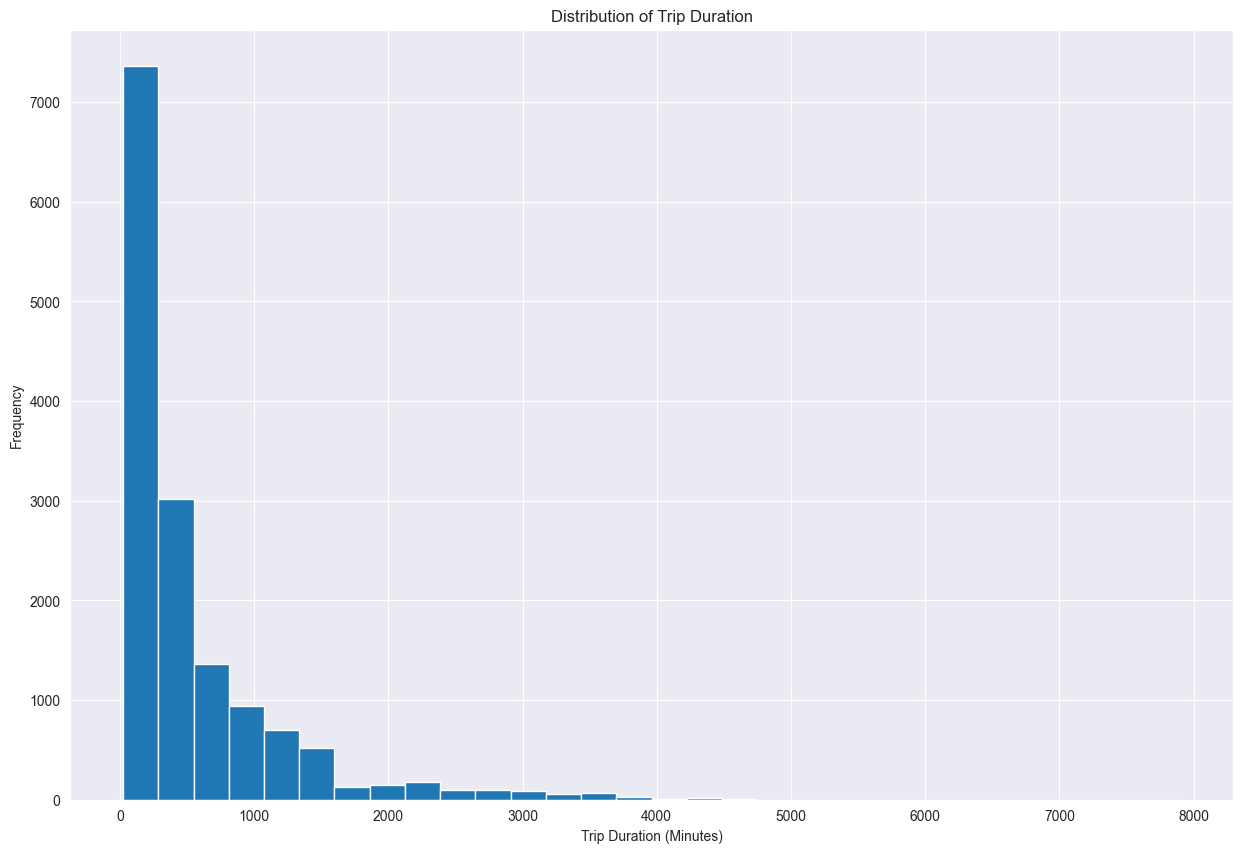

In [22]:
plt.figure(figsize = (15,10))
plt.hist(grouped_df['trip_duration_minutes'].dropna(), bins = 30)
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Duration')
plt.show()

Insights:

Histogram shows skewness and range of trip durations, hinting at potential delays

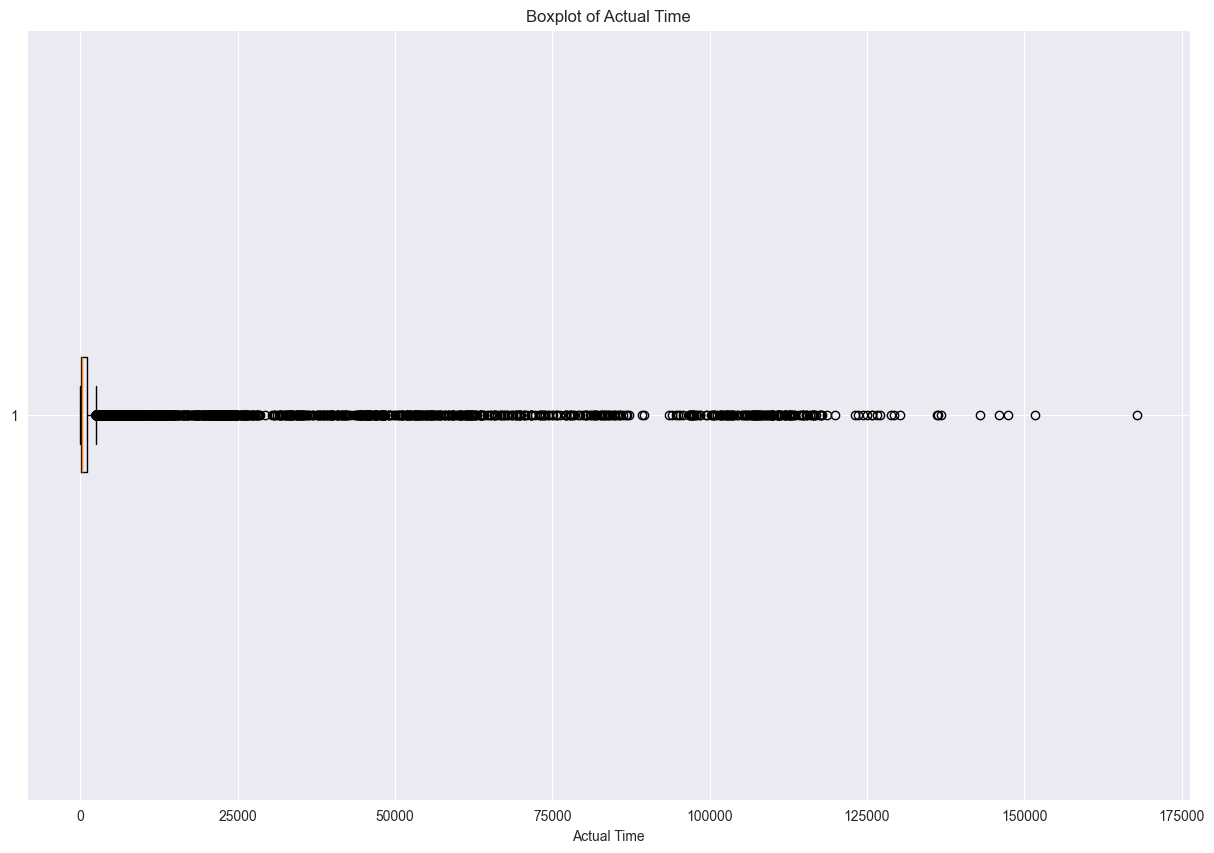

In [23]:
plt.figure(figsize = (15,10))
plt.boxplot(grouped_df['actual_time'].dropna(), vert = False)
plt.xlabel('Actual Time')
plt.title('Boxplot of Actual Time')
plt.show()

Insights:

Boxplot of actual times reveals the extent of outliers, which we will examine further.

## Bivariate Analysis

### Time-Related Comparisons

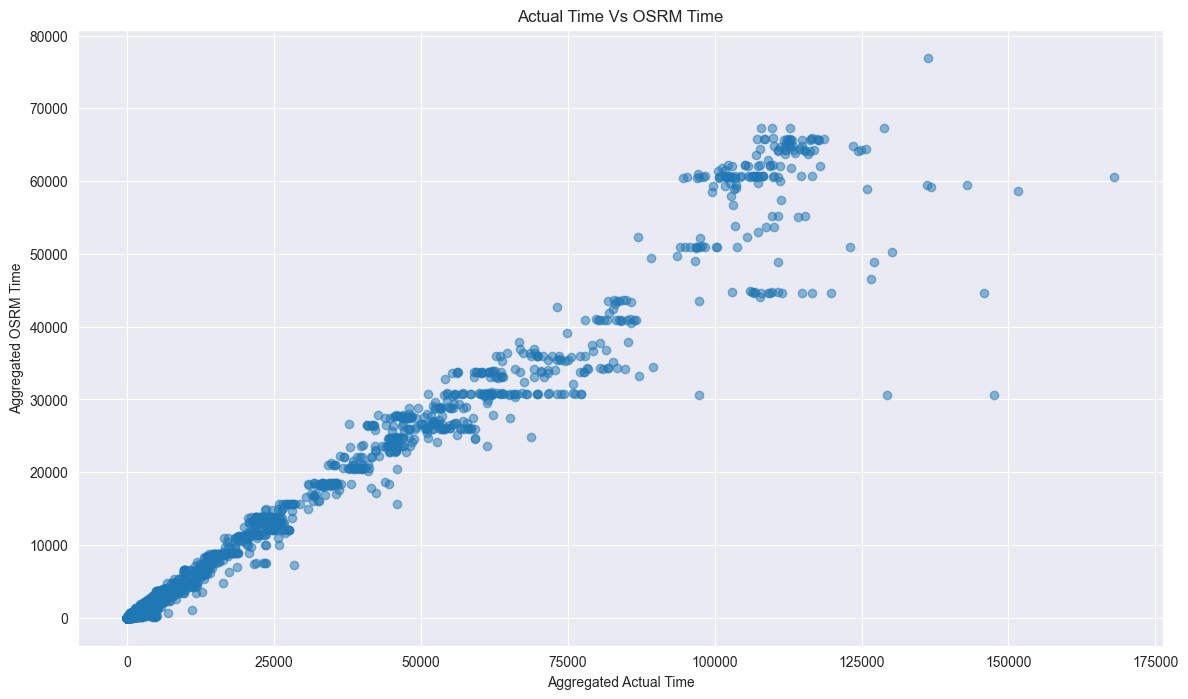

In [24]:
# Actual Time Versus OSRM Time
plt.figure(figsize = (14,8))
plt.scatter(grouped_df['actual_time'], grouped_df['osrm_time'], alpha = 0.5)
plt.xlabel('Aggregated Actual Time')
plt.ylabel('Aggregated OSRM Time')
plt.title('Actual Time Vs OSRM Time')
plt.show()

The plot shows a strong correlation between actual and OSRM times, meaning the route estimation model (OSRM) is generally performing well. However, some delays or inaccurate predictions are visible in longer trips and outlier cases, which may need further analysis.

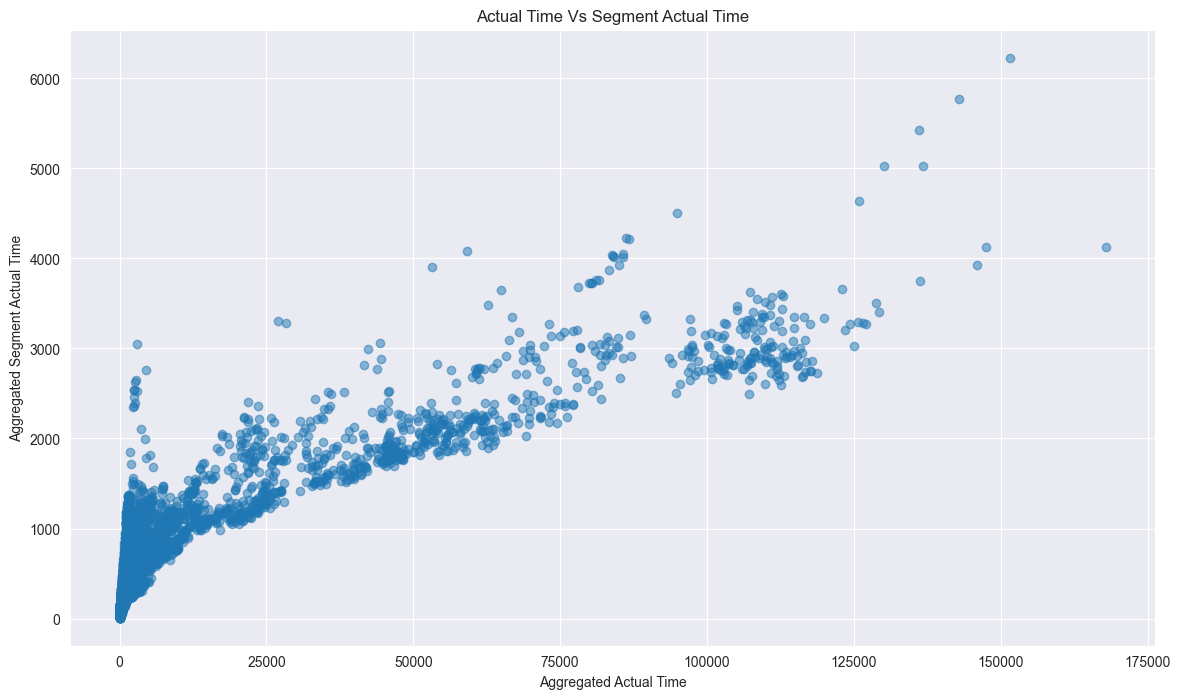

In [25]:
# Actual Time Versus Segment Actual Time
plt.figure(figsize = (14,8))
plt.scatter(grouped_df['actual_time'], grouped_df['segment_actual_time'], alpha = 0.5)
plt.xlabel('Aggregated Actual Time')
plt.ylabel('Aggregated Segment Actual Time')
plt.title('Actual Time Vs Segment Actual Time')
plt.show()

In [35]:
corr_actual_osrm = grouped_df['actual_time'].corr(grouped_df['osrm_time'])
corr_actual_segment = grouped_df['actual_time'].corr(grouped_df['segment_actual_time'])

print('Correlation between Actual and OSRM Time:', corr_actual_osrm)
print('Correlation between Actual and Segment Actual Time:', corr_actual_segment)

Correlation between Actual and OSRM Time: 0.9888803631615561
Correlation between Actual and Segment Actual Time: 0.8746848128120641


This comparison evaluates whether the sum of segment level actual time aligns with the total trip duration, helping to validate whether all phases of the delivery process are being accurately tracked. Significant gaps may indicate ineffeciencies such as idle time, delays between segments, or missing segment data.

### Distance-Related Comparisons

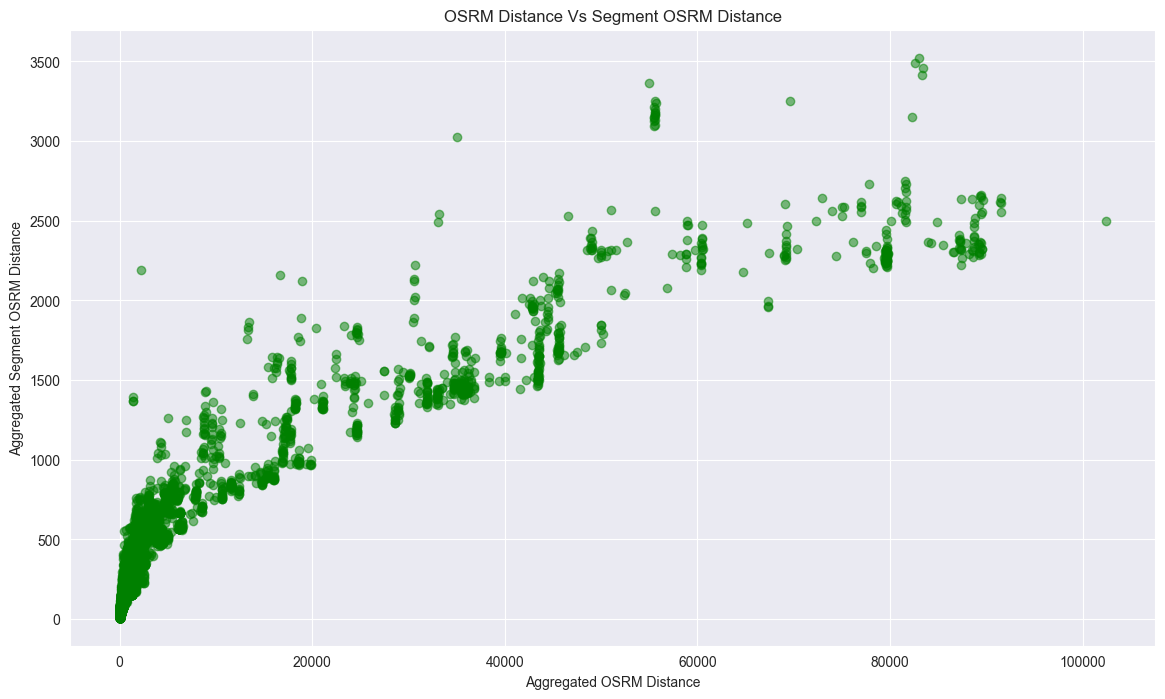

In [36]:
plt.figure(figsize = (14,8))
plt.scatter(grouped_df['osrm_distance'], grouped_df['segment_osrm_distance'], alpha = 0.5, color = 'green')
plt.xlabel('Aggregated OSRM Distance')
plt.ylabel('Aggregated Segment OSRM Distance')
plt.title('OSRM Distance Vs Segment OSRM Distance')
plt.show()

In [37]:
corr_distance = grouped_df['osrm_distance'].corr(grouped_df['segment_osrm_distance'])
print('Correlation between OSRM and Segment OSRM Distance:', corr_distance)

Correlation between OSRM and Segment OSRM Distance: 0.91117335478807


Mizoram requires a deeper analysis for logistics constraints, route planning or data errors.

Low duration states can be benchmarked for best practices.

### Relationships Between Aggregated Fields

In [43]:
fields_of_interest = ['actual_time', 'osrm_time','segment_actual_time', 'trip_duration_minutes', 'start_scan_to_end_scan']

corr_matrix = grouped_df_clean[fields_of_interest].corr()
print("Correlation Matrix:")
display(corr_matrix)

Correlation Matrix:


,actual_time,osrm_time,segment_actual_time,trip_duration_minutes,start_scan_to_end_scan
actual_time,1.000000,0.910085,0.804781,0.690781,0.500108
osrm_time,0.910085,1.000000,0.635377,0.589177,0.346412
segment_actual_time,0.804781,0.635377,1.000000,0.817520,0.592371
trip_duration_minutes,0.690781,0.589177,0.817520,1.000000,0.721685
start_scan_to_end_scan,0.500108,0.346412,0.592371,0.721685,1.000000


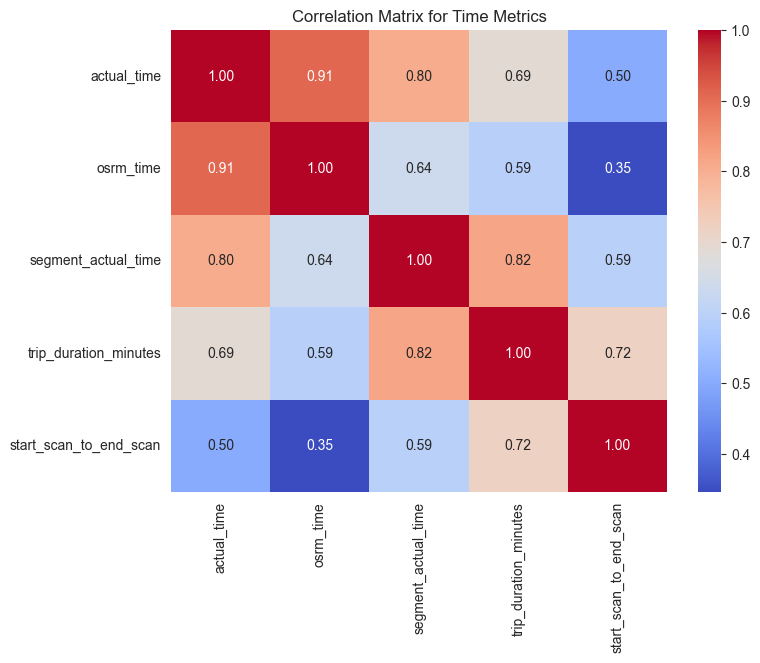

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix for Time Metrics')
plt.show()

Insights:
– The heatmap quantifies relationships among the aggregated fields, supporting visual analysis.
– High correlations validate that the OSRM and segment measures are largely in line with overall actual times, while deviations flag potential inefficiencies.

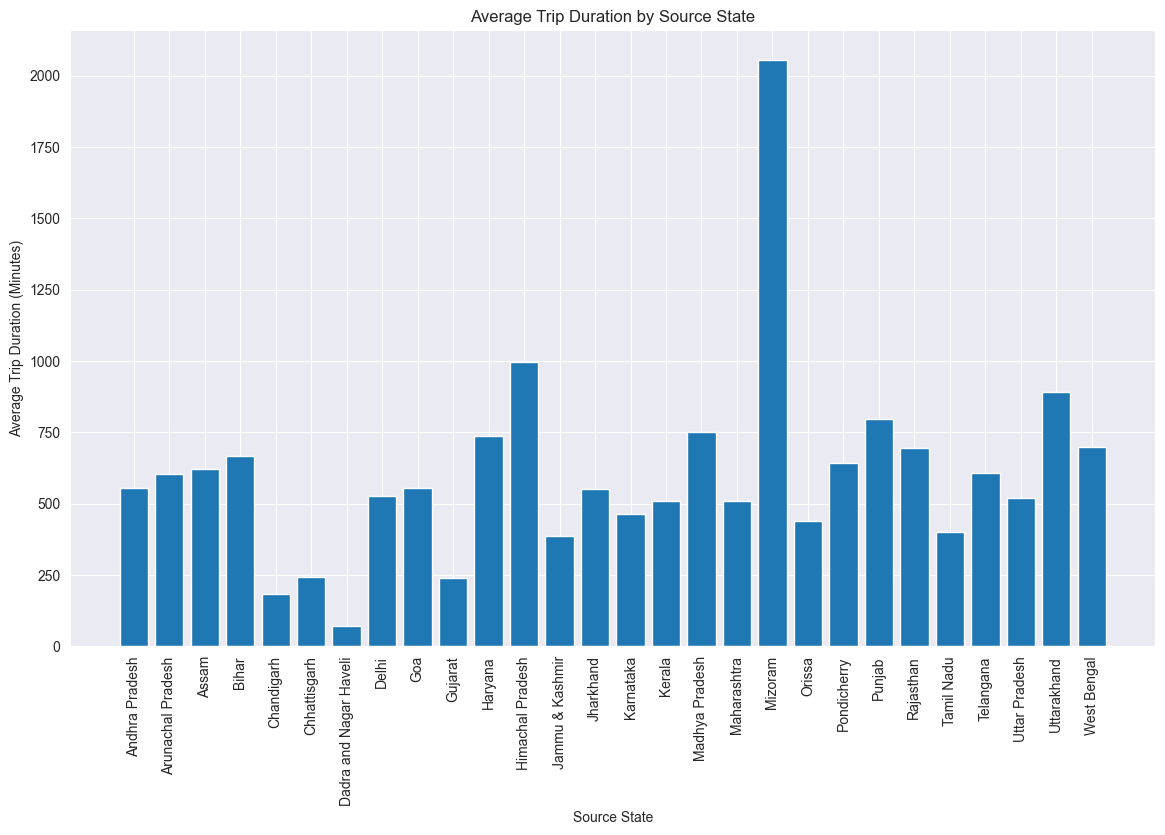

In [26]:
# State-wise & Corridor Analysis

state_duration = grouped_df.groupby('source_state')['trip_duration_minutes'].mean().reset_index()
state_counts = grouped_df['source_state'].value_counts().reset_index()

state_counts.columns = ['source_state', 'trip_count']

state_analysis = pd.merge(state_duration, state_counts, on = 'source_state')

plt.figure(figsize = (14,8))
plt.bar(state_analysis['source_state'], state_analysis['trip_duration_minutes'])
plt.xlabel('Source State')
plt.ylabel('Average Trip Duration (Minutes)')
plt.title('Average Trip Duration by Source State')
plt.xticks(rotation = 90)
plt.show()

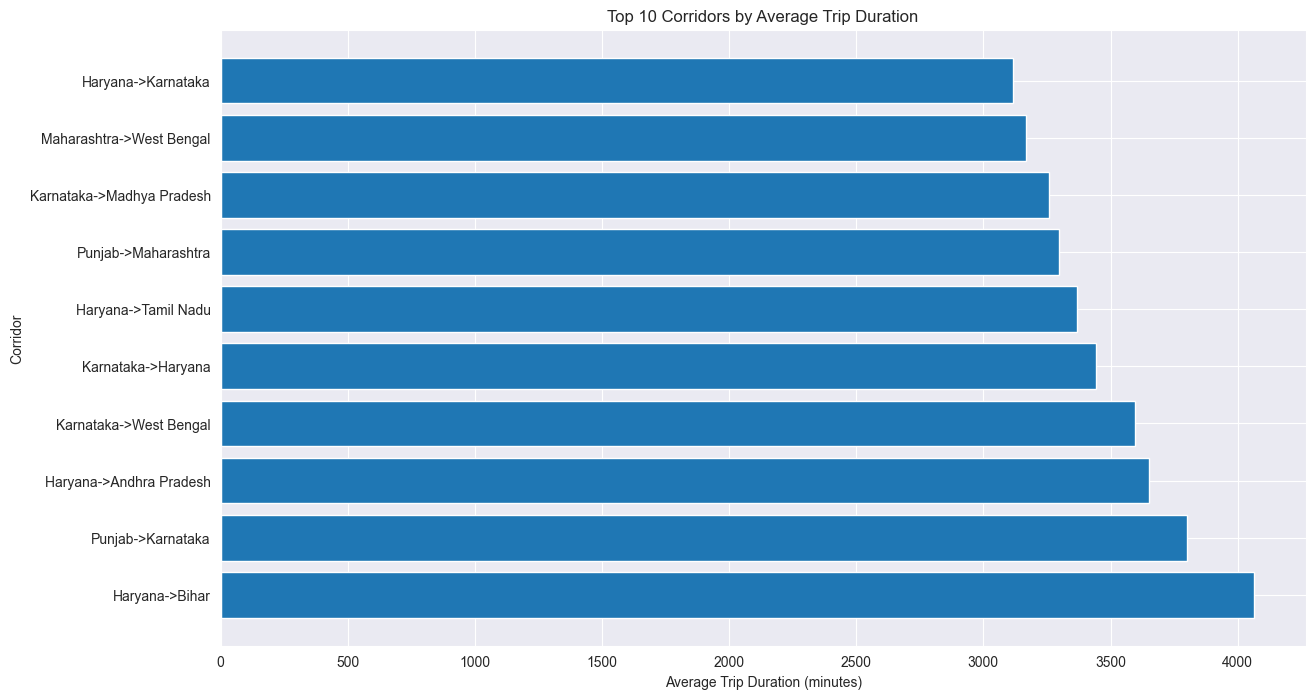

In [27]:
# Corridor / Central Hub Analysis

grouped_df['corridor'] = grouped_df['source_state'] + '->' + grouped_df['destination_state']

corridor_analysis = grouped_df.groupby('corridor')['trip_duration_minutes'].mean().reset_index()

top_corridors = corridor_analysis.sort_values(by = 'trip_duration_minutes', ascending = False).head(10)
plt.figure(figsize = (14,8))
plt.barh(top_corridors['corridor'], top_corridors['trip_duration_minutes'])
plt.xlabel('Average Trip Duration (minutes)')
plt.ylabel('Corridor')
plt.title('Top 10 Corridors by Average Trip Duration')
plt.show()

These top 10 corridors need attention for
*   Route optimization
*   Reducing transit delays
*   Evaluating carrier performance

Haryana and Karnataka as a source could be a focus area for operational improvement

# Outlier Detection & Treatment

In [38]:
missing_source = df['source_name'].isnull().sum()
missing_destination = df['destination_name'].isnull().sum()
print('Missing in source_name:', missing_source)
print('Missing in destination_name:', missing_destination)

df['source_name'].fillna(df['source_name'].mode()[0], inplace = True)
df['destination_name'].fillna(df['destination_name'].mode()[0], inplace = True)

Missing in source_name: 293
Missing in destination_name: 261


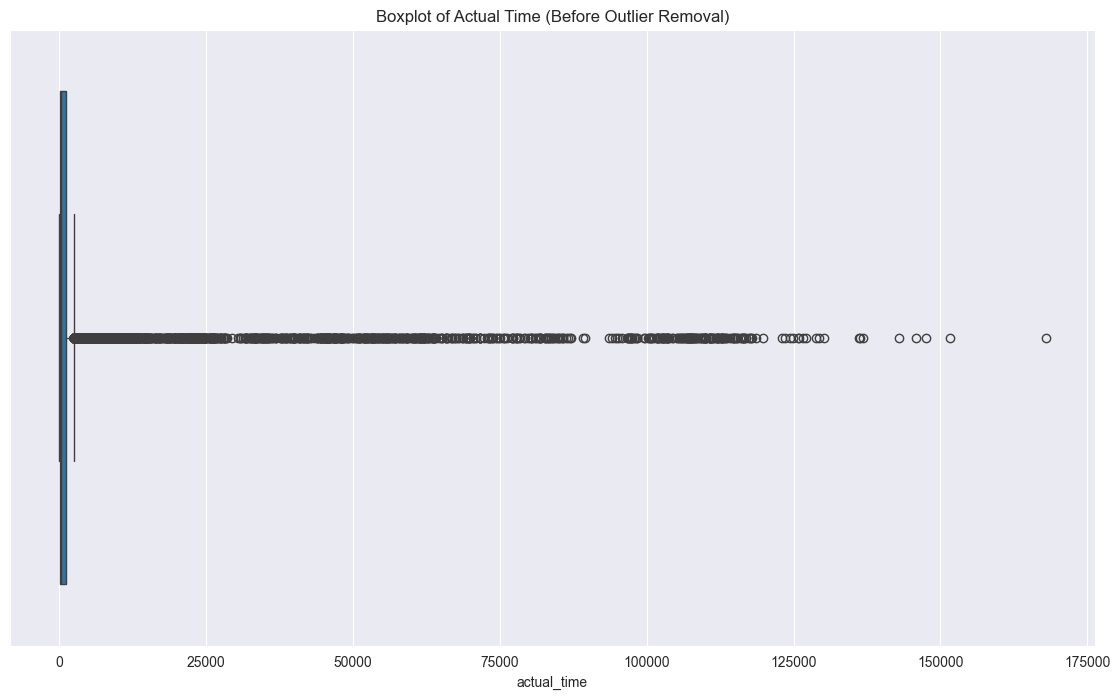

In [40]:
# Before outlier removal: visualize actual_time

plt.figure(figsize=(14,8))
sns.boxplot(x = grouped_df['actual_time'])
plt.title('Boxplot of Actual Time (Before Outlier Removal)')
plt.show()

In [39]:
def remove_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

grouped_df_clean = remove_outliers(grouped_df, 'actual_time')
print("Original Shape:", grouped_df.shape, "After outlier treatment:", grouped_df_clean.shape)

Original Shape: (14817, 20) After outlier treatment: (12747, 20)


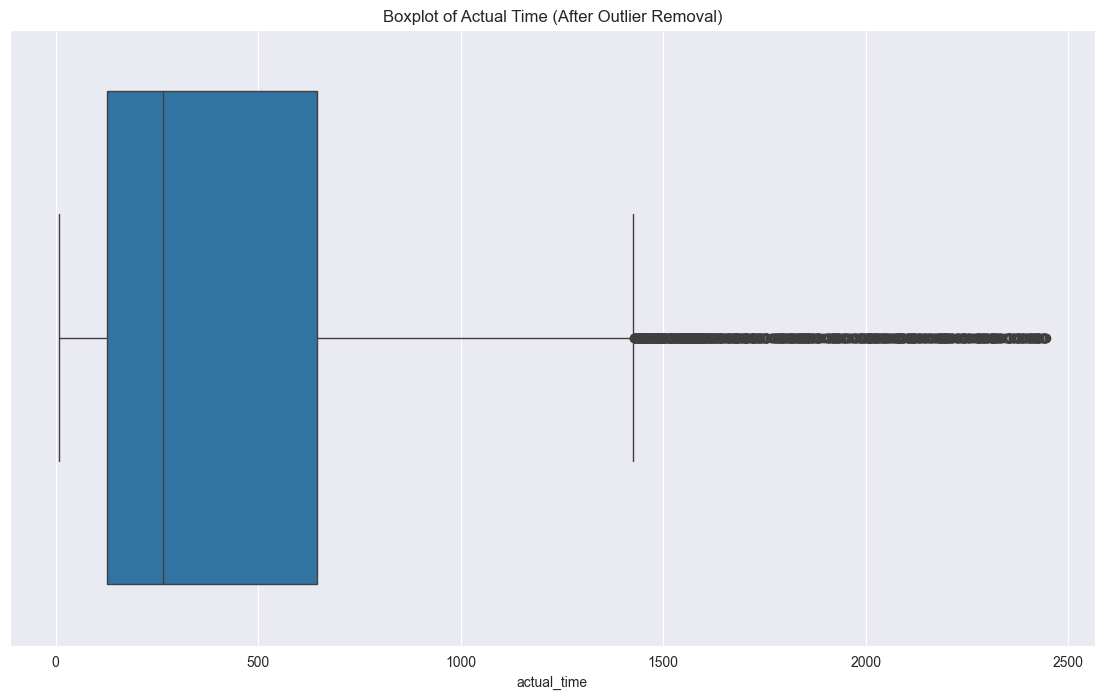

In [42]:
# Visualize again after outlier removal

plt.figure(figsize = (14,8))
sns.boxplot(x = grouped_df_clean['actual_time'])
plt.title('Boxplot of Actual Time (After Outlier Removal)')
plt.show()

Removing outliers stabilizes aggregate metrics and prevents a few extreme trips from skewing the analysis.

# Categorical Encoding and Normalization

## One-Hot Encoding

In [46]:
print("Route Type Distribution:")
print(df['route_type'].value_counts())

print("Source State Distribution:")
print(df['source_state'].value_counts())

print("Destination State Distribution:")
print(df['destination_state'].value_counts())

grouped_df_encoded = pd.get_dummies(grouped_df_clean, columns = ['route_type'], drop_first=True)

print('Encoded Dataframe Sample:')
display(grouped_df_encoded.head())

Route Type Distribution:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64
Source State Distribution:
source_state
Haryana                   26942
Maharashtra               18997
Karnataka                 18534
Tamil Nadu                 6697
Telangana                  6212
Andhra Pradesh             5087
Uttar Pradesh              4791
West Bengal                4743
Delhi                      4318
Madhya Pradesh             3687
Rajasthan                  3530
Punjab                     3381
Bihar                      2206
Kerala                     2038
Gujarat                    1867
Jharkhand                  1343
Assam                      1126
Uttarakhand                 827
Himachal Pradesh            532
Orissa                      404
Chandigarh                  367
Chhattisgarh                229
Jammu & Kashmir             182
Goa                         165
Arunachal Pradesh           151
Meghalaya                    77
Pondicherry                  49


,trip_uuid,trip_creation_time,route_schedule_uuid,source_center,destination_center,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,trip_duration_minutes,source_state,destination_state,corridor,route_type_FTL
1,trip-153671042288605164,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,58.0,26.689812,399.0,210.0,269.4308,141.0,65.0,84.1894,181.611874,Karnataka,Karnataka,Karnataka->Karnataka,False
3,trip-153671046011330457,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,IND400072AAB,IND401104AAA,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,100.0,14.264824,82.0,24.0,31.6475,59.0,16.0,19.8766,100.494935,NaN,Maharashtra,NaN,False
4,trip-153671052974046625,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,IND583101AAA,IND583201AAA,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,485.0,34.143901,556.0,207.0,266.2914,340.0,115.0,146.7919,718.349042,NaN,NaN,NaN,True
5,trip-153671055416136166,2018-09-12 00:02:34.161600,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,IND600116AAB,IND600056AAA,2018-09-12 00:02:34.161600,2018-09-12 03:13:03.432532,60.0,11.469288,92.0,30.0,38.1953,60.0,23.0,28.0647,190.487849,Tamil Nadu,NaN,NaN,False
6,trip-153671066201138152,2018-09-12 00:04:22.011653,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,IND600044AAD,IND600048AAA,2018-09-12 00:04:22.011653,2018-09-12 01:42:22.349694,98.0,9.100510,24.0,13.0,12.0184,24.0,13.0,12.0184,98.005634,Tamil Nadu,Tamil Nadu,Tamil Nadu->Tamil Nadu,False


# Normalization of Numerical Features

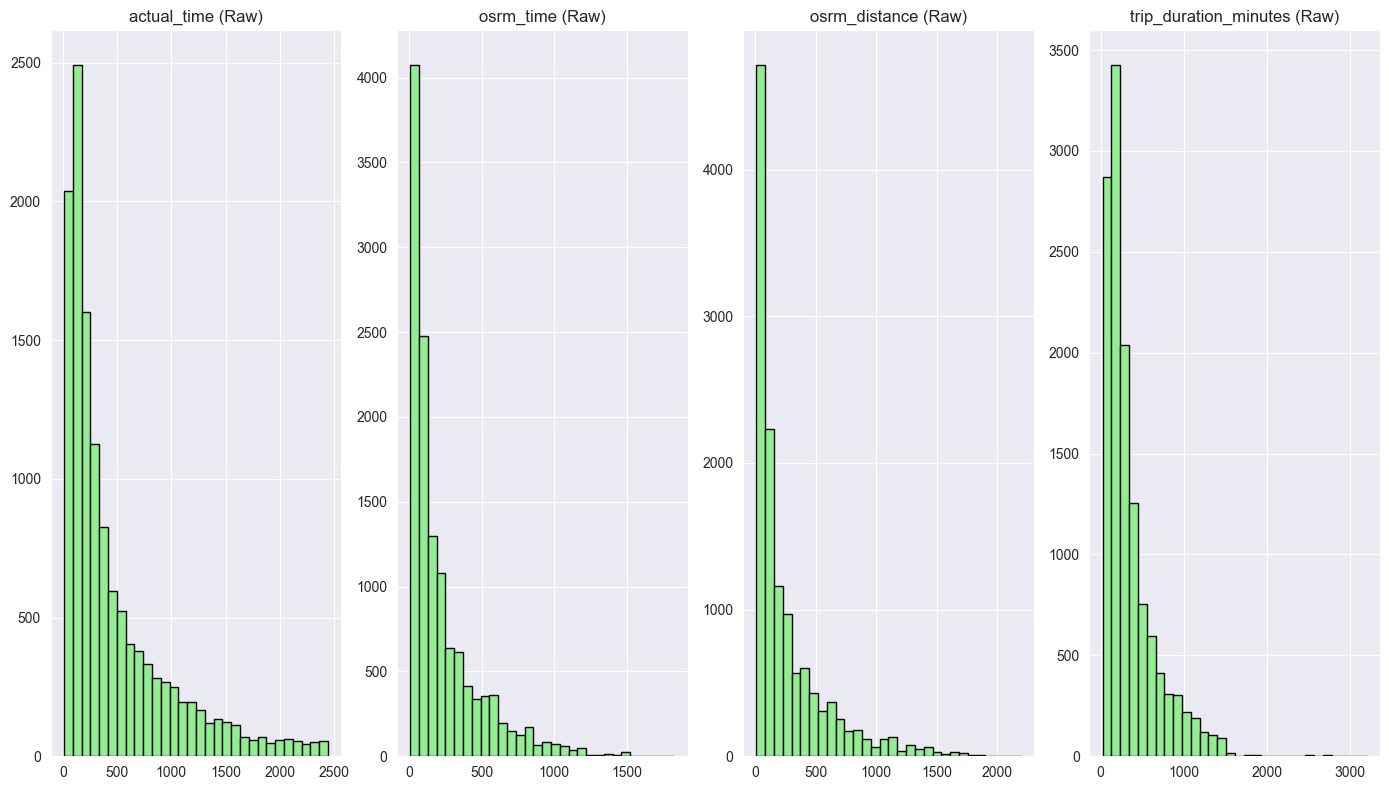

In [47]:
numeric_cols = ['actual_time', 'osrm_time', 'osrm_distance', 'trip_duration_minutes']

# Visualize distributions before scaling
fig, ax = plt.subplots(1, len(numeric_cols), figsize = (14,8))
for i, col in enumerate(numeric_cols):
    ax[i].hist(grouped_df_encoded[col].dropna(), bins = 30, color = 'lightgreen', edgecolor = 'black')
    ax[i].set_title(f'{col} (Raw)')
plt.tight_layout()
plt.show()

In [48]:
# Standard Scaler Normalization

std_scaler = StandardScaler()
grouped_df_encoded_std = grouped_df_encoded.copy()
grouped_df_encoded_std[numeric_cols] = std_scaler.fit_transform(grouped_df_encoded_std[numeric_cols])

In [49]:
# MinMaxScaler Normalization

minmax_scaler = MinMaxScaler()
grouped_df_encoded_mm = grouped_df_encoded.copy()
grouped_df_encoded_mm[numeric_cols] = minmax_scaler.fit_transform(grouped_df_encoded_mm[numeric_cols])

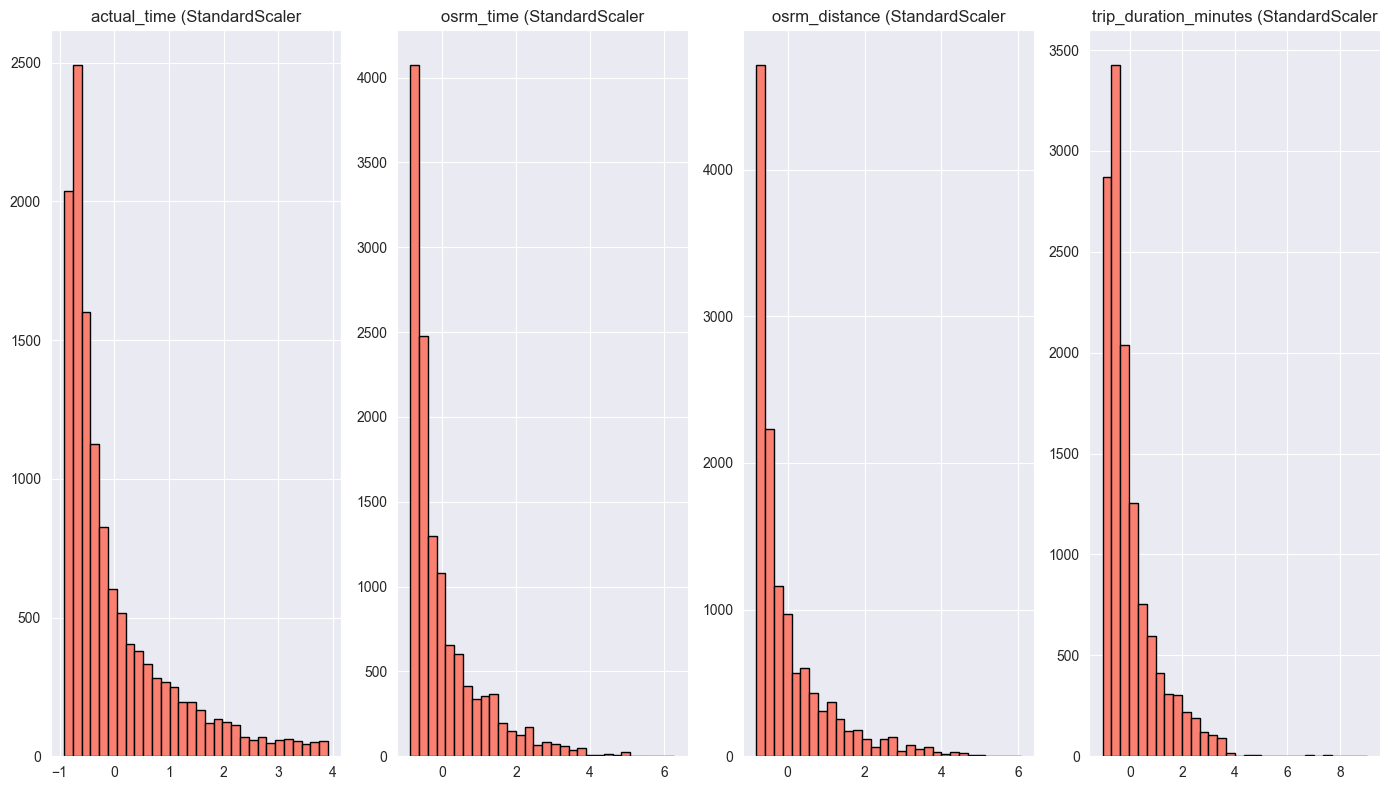

In [50]:
# Visualize distributions after scaling with StandardScaler

fig, ax = plt.subplots(1, len(numeric_cols), figsize = (14,8))
for i, col in enumerate(numeric_cols):
    ax[i].hist(grouped_df_encoded_std[col], bins = 30, color = 'salmon', edgecolor = 'black')
    ax[i].set_title(f'{col} (StandardScaler')
plt.tight_layout()
plt.show()

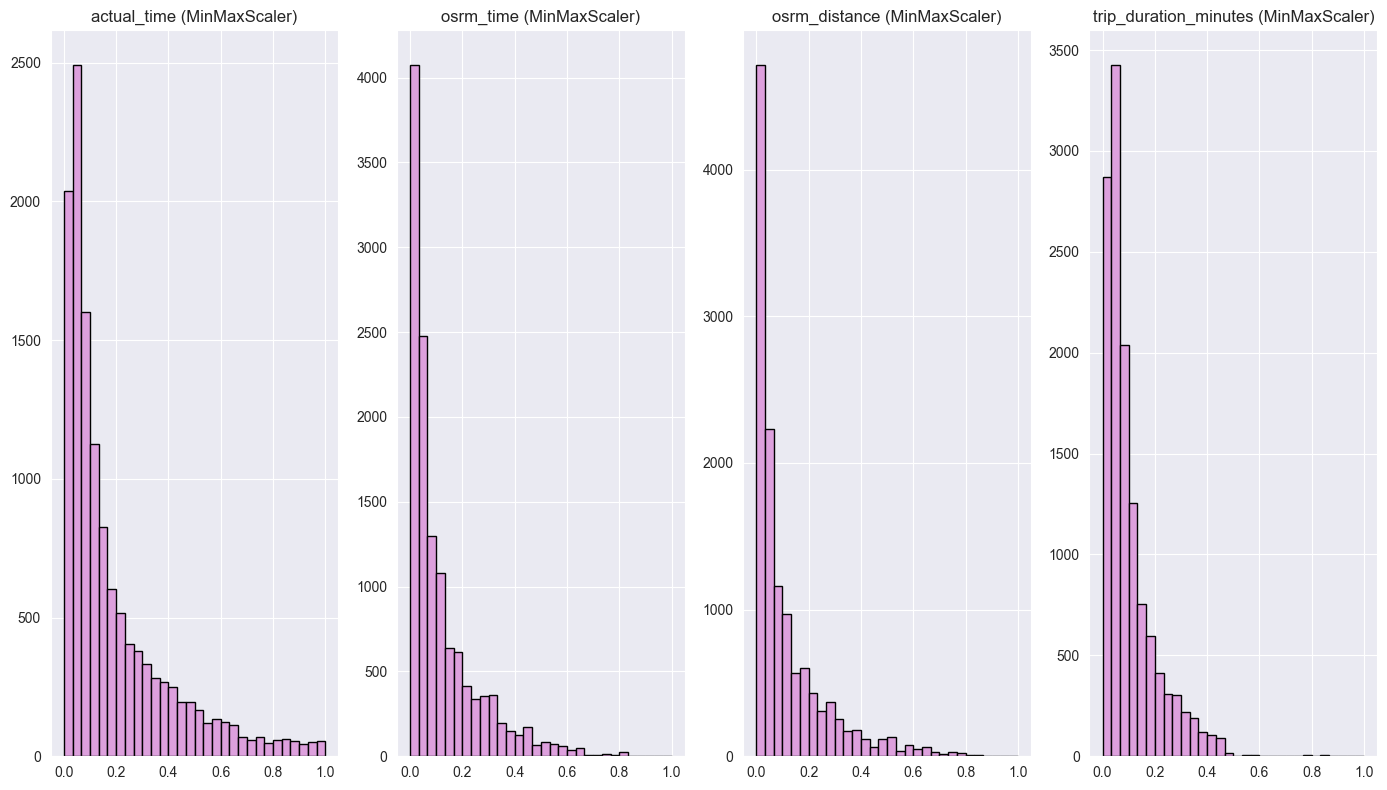

In [51]:
# Visualize distributions after scaling with MinMaxScaler

fig, ax = plt.subplots(1, len(numeric_cols), figsize = (14,8))
for i, col in enumerate(numeric_cols):
    ax[i].hist(grouped_df_encoded_mm[col], bins = 30, color = 'plum', edgecolor = 'black')
    ax[i].set_title(f'{col} (MinMaxScaler)')
plt.tight_layout()
plt.show()

Normalization is crucial when comparing features with different scales, ensuring visual analysis and any modelling are not biased due to numeric ranges.

# In-depth Analysis & Hypothesis Testing

## Comparing Time Metrics

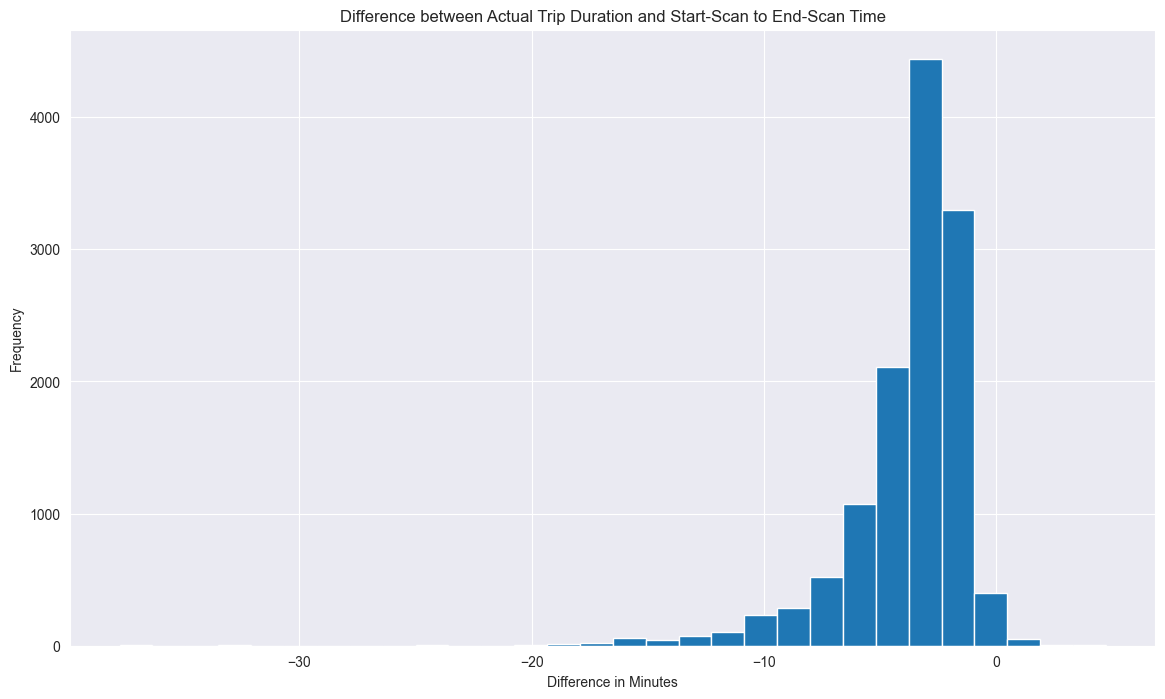

In [31]:
grouped_df_encoded['time_diff_minutes'] = grouped_df_encoded['trip_duration_minutes'] - grouped_df_encoded['start_scan_to_end_scan'] / 60

plt.figure(figsize = (14,8))
plt.hist(grouped_df_encoded['time_diff_minutes'].dropna(), bins = 30)
plt.xlabel('Difference in Minutes')
plt.ylabel('Frequency')
plt.title('Difference between Actual Trip Duration and Start-Scan to End-Scan Time')
plt.show()

Most trips take slightly longer than what scan times indicate, with a typical difference of 2-10 minutes. This gap could be due to operational steps outside scan events, such as loading / unloading or driver-level delays. Incorporating this buffer in analytics could lead to more realistic trip time estimates.

## OSRM Vs Actual and Segment Times

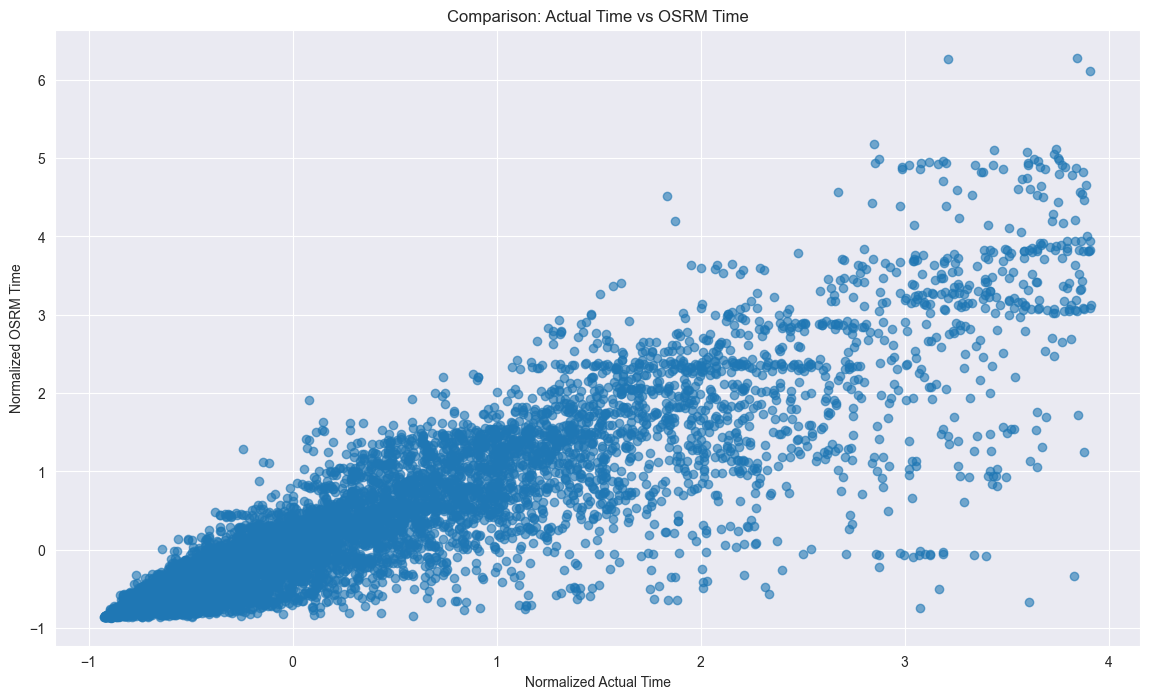

In [32]:
# OSRM Vs Actual Time
plt.figure(figsize = (14,8))
plt.scatter(grouped_df_encoded['actual_time'], grouped_df_encoded['osrm_time'], alpha = 0.6)
plt.xlabel('Normalized Actual Time')
plt.ylabel('Normalized OSRM Time')
plt.title('Comparison: Actual Time vs OSRM Time')
plt.show()

The OSRM Model aligns well with actual delivery time for most trips, but accurately declines for longer or outlier trips. This suggests the need for enhanced prediction models that factor in real-world delays, geography, or hub-related slowdowns.

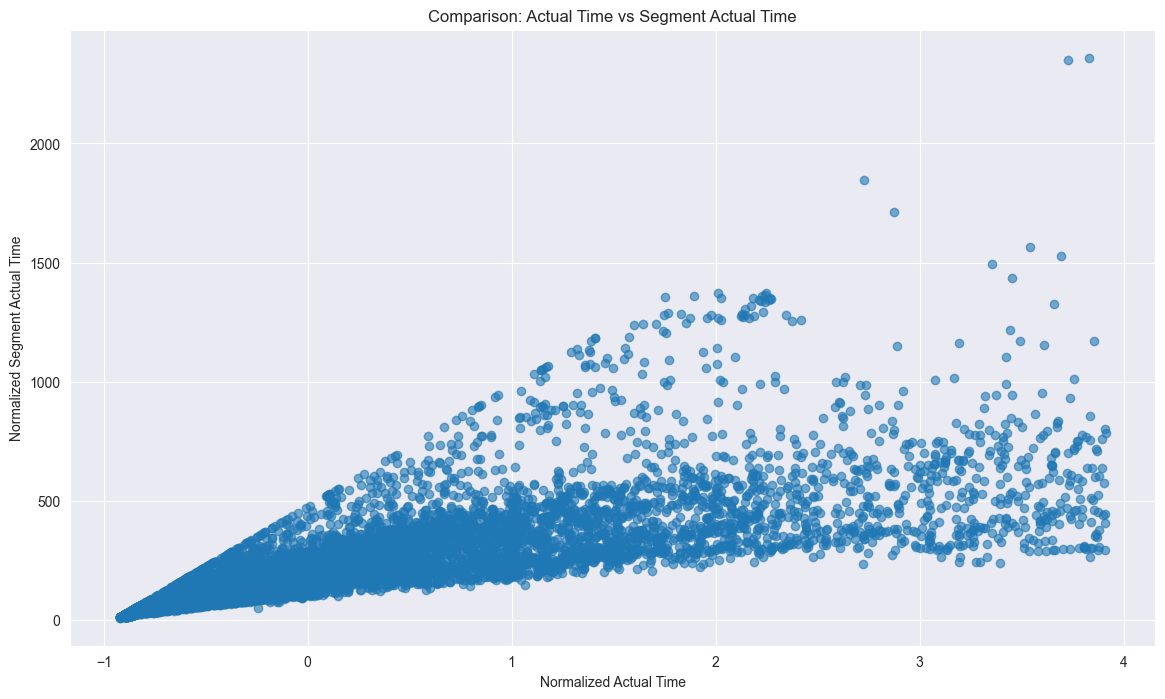

In [33]:
# OSRM Vs Segment Actual Time
plt.figure(figsize = (14,8))
plt.scatter(grouped_df_encoded['actual_time'], grouped_df_encoded['segment_actual_time'], alpha = 0.6)
plt.xlabel('Normalized Actual Time')
plt.ylabel('Normalized Segment Actual Time')
plt.title('Comparison: Actual Time vs Segment Actual Time')
plt.show()

While there’s an overall positive trend between actual trip time and segment time, significant variance—especially for longer trips—indicates potential inefficiencies, delays, or tracking issues not captured in segment logs. Addressing these could improve visibility into true delivery performance.

# Business Insights

## State-wise Performance and Bottlenecks

High Average Trip Duration:

*   Certain source states exhibit significantly higher average trip
durations. This could be due to regional traffic issues, suboptimal routing, or local infrastructural challenges.
*   For example, state-wise grouping may reveal that hubs in a particular state are slower, indicating a need for process review or infrastructure upgrades.


Trip Volume vs. Efficiency:

*   States with a high number of orders (trip count) may experience operational strain. Cross-referencing order volume with average trip durations highlights states where capacity enhancement should be prioritized.

## Corridor / Central Hub Efficiency

Corridor Analysis:

*   Specific corridors (e.g., from one state to another) demonstrate outlier durations. These corridors require in-depth investigation to determine if delays are systemic (e.g., due to longer distances or traffic) or procedural (e.g., scanning delays).
*   A comparative analysis between the OSRM estimated durations and actual durations indicates whether the current routing models capture real-world conditions accurately.

## Time Metric Discrepancies

Scanning vs. Actual Times:

*   The distribution of differences between the computed trip duration and the start-to-scan time suggests that delays may occur during the handover or processing intervals.
*   These delays could be mitigated with process improvements or additional monitoring measures.

# Recommendations

Based on the above findings, our recommendations include:

Optimize Underperforming Corridors:
*   Focus on corridors and states with higher-than-average trip durations by reviewing the routing algorithms and operational strategies.
*   Implement dynamic routing strategies or reallocate resources during known peak hours.

Infrastructure Investment in Busy Hubs:
Prioritize capacity upgrades and process audits in states with high trip volumes and prolonged average delivery times.

Enhanced Process Monitoring:
Introduce real-time monitoring of scanning times and handover processes to identify and rectify delays before they impact overall delivery performance.

Refine Forecasting Models:
Incorporate both OSRM and segment-level time data into predictive models to better capture the variability of real-world operations.

State-specific Action Plans:
Develop tailored interventions for each state based on its unique performance indicators, ensuring that recommendations are actionable at a regional level.

# Conclusion

This comprehensive assignment report outlines the full journey from data ingestion and cleaning to exploratory and hypothesis-driven analyses, culminating in actionable business insights.

*   Data Processing: We transformed raw, multi-row delivery data into a trip-level summary; handled missing values, outliers, and extracted critical time and location features.
*   Analytical Insights: Our exploration through state-wise and corridor analyses reveals where operational delays occur and which regions or routes lag in performance relative to OSRM estimates.
*   Actionable Outcomes: The insights support targeted infrastructure improvements and process refinements, helping Delhivery maintain its market leadership through data-driven decisions.


Each code block and visualization has been accompanied by direct commentary, ensuring that the insights are transparently linked to the data at every step. This submission demonstrates the rigorous analytical approach required to tackle uncertainty and extract tangible business value from operational data.